In [2]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import scipy.stats as stats

# python font no dingbattes
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [ ]:
#open the output file

import os

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/2bins/SHM_T1.pkl'
with open(file_path, 'rb') as f:
    data_neutral_T1 = pkl.load(f)
    
file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/2bins/SHM_T2.pkl'
with open(file_path, 'rb') as f:
    data_neutral_T2 = pkl.load(f)
    
file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/Spline_nt/2bins/SHM_FO.pkl'
with open(file_path, 'rb') as f:
    data_neutral_FO = pkl.load(f)
    
    



In [4]:
# open experimental data file 
df = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/new_data_MZB.csv')
df = df.sort_values(by='Age at S1K')
df.loc[1, 'Age at BMT'] = 74
print(df)


                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          74          88   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [5]:
#Add one column in df_Ki67 and df_Nfd for grouping the data based on age at bmt

df['agebin'] = pd.cut(df['Age at BMT'], bins=[0,70, 140], labels=['<10 weeks', '>10 weeks'])
print(df)

                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          74          88   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [6]:
# my_pal = ['#FAA51A','#984763','#2e2976']
my_pal = ["#f99f1b", "#282a73"]


In [7]:
data_neutral_T1.host_ki_pred2.shape

(8000, 662)

In [8]:
#Filter predicted values 
MZ_predT1 = data_neutral_T1.MZ_counts_pred1[:, 7:]
Nfd_predT1 = data_neutral_T1.Nfd_pred1[:, 7:]
ki_host_predT1 = data_neutral_T1.host_ki_pred1[:, 7:]
ki_donor_predT1 = data_neutral_T1.donor_ki_pred1[:, 7:]

MZ_predT2 = data_neutral_T2.MZ_counts_pred1[:, 7:]
Nfd_predT2 = data_neutral_T2.Nfd_pred1[:, 7:]
ki_host_predT2 = data_neutral_T2.host_ki_pred1[:, 7:]
ki_donor_predT2 = data_neutral_T2.donor_ki_pred1[:, 7:]

MZ_predFO = data_neutral_FO.MZ_counts_pred1[:, 7:]
Nfd_predFO = data_neutral_FO.Nfd_pred1[:, 7:]
ki_host_predFO = data_neutral_FO.host_ki_pred1[:, 7:]
ki_donor_predFO = data_neutral_FO.donor_ki_pred1[:, 7:]


/tmp/ipykernel_692082/3076071886.py:27: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


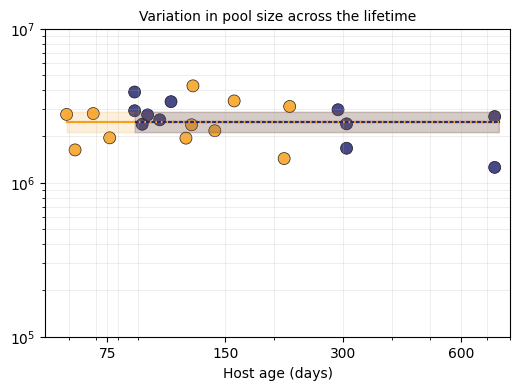

In [9]:
#Plot Mz counts for three precursors
ts1= np.arange(59, 750, 1)
ts2= np.arange(88, 750, 1)

plt.figure(figsize=(6, 4))

sns.scatterplot(data=df, x='Age at S1K', y='total_MZ', alpha=0.85, hue='agebin', edgecolor='black', s=75, linewidth=0.5, legend=False, palette=my_pal)
plt.plot(ts1, np.mean(MZ_predT1, axis=0), color=my_pal[0], linestyle='dashed')
plt.plot(ts2, np.mean(data_neutral_T1.MZ_counts_pred2, axis=0), color=my_pal[1], linestyle='dashed')
plt.fill_between(ts1, np.quantile(MZ_predT1, 0.025, axis=0), np.quantile(MZ_predT1, 0.975, axis=0), alpha=0.05, color=my_pal[0])
plt.fill_between(ts2, np.quantile(data_neutral_T1.MZ_counts_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.MZ_counts_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])

plt.plot(ts1, np.mean(MZ_predT2, axis=0), color=my_pal[0])
plt.plot(ts2, np.mean(data_neutral_T2.MZ_counts_pred2, axis=0), color=my_pal[1])
plt.fill_between(ts1, np.quantile(MZ_predT2, 0.025, axis=0), np.quantile(MZ_predT2, 0.975, axis=0), alpha=0.05, color=my_pal[0])
plt.fill_between(ts2, np.quantile(data_neutral_T2.MZ_counts_pred2, 0.025, axis=0), np.quantile(data_neutral_T2.MZ_counts_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])

plt.plot(ts1, np.mean(MZ_predFO, axis=0), color=my_pal[0], linestyle='dotted')
plt.plot(ts2, np.mean(data_neutral_FO.MZ_counts_pred2, axis=0), color=my_pal[1], linestyle='dotted')
plt.fill_between(ts1, np.quantile(MZ_predFO, 0.025, axis=0), np.quantile(MZ_predFO, 0.975, axis=0), alpha=0.05, color=my_pal[0])
plt.fill_between(ts2, np.quantile(data_neutral_FO.MZ_counts_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.MZ_counts_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])


plt.yscale('log')  # sets the y-axis to a logarithmic scale
plt.ylim(1e5, 1e7)
plt.xscale('log')
plt.xlim(0, 800)
plt.xticks([75, 150, 300, 600], [75, 150, 300, 600])
plt.ylabel('')
plt.tick_params(axis='both', labelsize=10)
plt.xlabel('Host age (days)', fontsize=10)
plt.title('Variation in pool size across the lifetime', fontsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.tight_layout()
#Save the figure
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_Counts.pdf', dpi=300, bbox_inches='tight')
plt.show()    



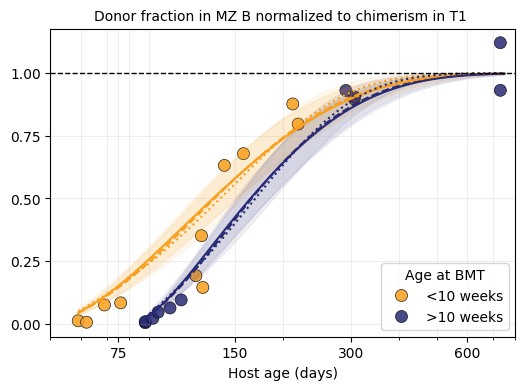

In [10]:
#PLOT Nfd


plt.figure(figsize=(6, 4))

sns.scatterplot(data=df, x='Age at S1K', y='Nfd_MZ', hue='agebin', edgecolor='black', linewidth=0.5, alpha=0.85, s=75, legend= True, palette=my_pal)
plt.plot(ts1, np.mean(Nfd_predT1, axis=0), color=my_pal[0], linestyle='dashed')
plt.plot(ts2, np.mean(data_neutral_T1.Nfd_pred2, axis=0), color=my_pal[1], linestyle='dashed')
plt.fill_between(ts1, np.quantile(Nfd_predT1, 0.025, axis=0), np.quantile(Nfd_predT1, 0.975, axis=0), alpha=0.065, color=my_pal[0])
plt.fill_between(ts2, np.quantile(data_neutral_T1.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.Nfd_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])

plt.plot(ts1, np.mean(Nfd_predT2, axis=0), color=my_pal[0])
plt.plot(ts2, np.mean(data_neutral_T2.Nfd_pred2, axis=0), color=my_pal[1])
plt.fill_between(ts1, np.quantile(Nfd_predT2, 0.025, axis=0), np.quantile(Nfd_predT2, 0.975, axis=0), alpha=0.065, color=my_pal[0])
plt.fill_between(ts2, np.quantile(data_neutral_T2.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral_T2.Nfd_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])

plt.plot(ts1, np.mean(Nfd_predFO, axis=0), color=my_pal[0], linestyle ='dotted')
plt.plot(ts2, np.mean(data_neutral_FO.Nfd_pred2, axis=0), color=my_pal[1], linestyle='dotted')
plt.fill_between(ts1, np.quantile(Nfd_predFO, 0.025, axis=0), np.quantile(Nfd_predFO, 0.975, axis=0), alpha=0.065, color=my_pal[0])
plt.fill_between(ts2, np.quantile(data_neutral_FO.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.Nfd_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])


plt.xlim(50, 800)
plt.xscale('log')
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
plt.xlabel('Host age (days)', fontsize=10)
plt.title('Donor fraction in MZ B normalized to chimerism in T1 ', fontsize=10)
plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1)
plt.tick_params(axis='both', labelsize=10)
plt.legend(title='Age at BMT', fontsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_Nfd.pdf', dpi=300)
plt.show() 


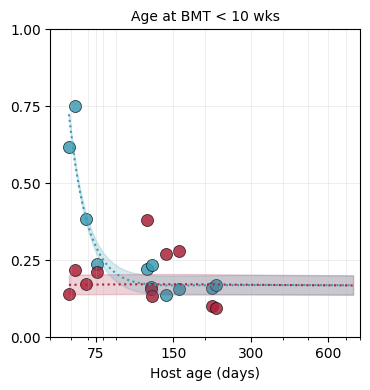

In [12]:

#Construct a new dataframe for agebin1, agebin2 
df_Ki67_bin1 = df[df['agebin'] == '<10 weeks']
df_Ki67_bin2 = df[df['agebin'] == '>10 weeks']


plt.figure(figsize=(4, 4))
sns.scatterplot(data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.5, alpha=0.85, s=75, color='#3b9bb3')
sns.scatterplot(data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_host',edgecolor='black', linewidth=0.5, alpha=0.85, s=75, color='#ab2239')


# plt.plot(ts1, np.mean(ki_host_predT1 , axis=0), color='#ab2239', linestyle='dashed')
# plt.fill_between(ts1, np.quantile(ki_host_predT1 , 0.025, axis=0), np.quantile(ki_host_predT1 , 0.975, axis=0), color='#ab2239', alpha=0.2)
# plt.plot(ts1, np.mean(ki_donor_predT1, axis=0), color='#3b9bb3', linestyle='dashed')
# plt.fill_between(ts1, np.quantile(ki_donor_predT1, 0.025, axis=0), np.quantile(ki_donor_predT1, 0.975, axis=0), color='#3b9bb3', alpha=0.2)


# plt.plot(ts1, np.mean(ki_host_predT2 , axis=0), color='#ab2239')
# plt.fill_between(ts1, np.quantile(ki_host_predT2 , 0.025, axis=0), np.quantile(ki_host_predT2 , 0.975, axis=0), color='#ab2239', alpha=0.2)
# plt.plot(ts1, np.mean(ki_donor_predT2, axis=0), color='#3b9bb3')
# plt.fill_between(ts1, np.quantile(ki_donor_predT2, 0.025, axis=0), np.quantile(ki_donor_predT2, 0.975, axis=0), color='#3b9bb3', alpha=0.2)


plt.plot(ts1, np.mean(ki_host_predFO , axis=0), color='#ab2239', linestyle='dotted')
plt.fill_between(ts1, np.quantile(ki_host_predFO , 0.025, axis=0), np.quantile(ki_host_predFO , 0.975, axis=0), color='#ab2239', alpha=0.2)
plt.plot(ts1, np.mean(ki_donor_predFO, axis=0), color= '#3b9bb3', linestyle='dotted')
plt.fill_between(ts1, np.quantile(ki_donor_predFO, 0.025, axis=0), np.quantile(ki_donor_predFO, 0.975, axis=0), color= '#3b9bb3', alpha=0.2)


plt.xlim(50, 800)
plt.ylim(0, 1)
plt.xscale('log')
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
# plt.ylabel('Proportion of Ki67+ MZ cells', fontsize=10)
plt.title('Age at BMT < 10 wks', fontsize=10)
plt.xlabel('Host age (days)', fontsize=10)
# plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1)
plt.tick_params(axis='both', labelsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
# plt.legend(labels=['Donor', 'Host'])
# plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_Ki67Bin1_FO.pdf', dpi=300)
plt.show() 

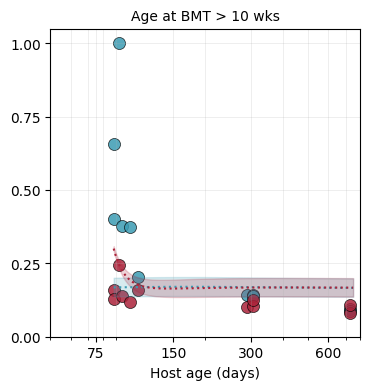

In [13]:

plt.figure(figsize=(4, 4))
sns.scatterplot(data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.5, alpha=0.85, s=75, color='#3b9bb3')
sns.scatterplot(data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_host', edgecolor='black', linewidth=0.5, alpha=0.85, s=75, color='#ab2239')

# plt.plot(ts2, np.mean(data_neutral_T1.host_ki_pred2, axis=0), color='#ab2239', linestyle='dashed')
# plt.fill_between(ts2, np.quantile(data_neutral_T1.host_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.host_ki_pred2, 0.975, axis=0), color= '#ab2239', alpha=0.2)
# plt.plot(ts2, np.mean(data_neutral_T1.donor_ki_pred2, axis=0), color = '#3b9bb3', linestyle='dashed')
# plt.fill_between(ts2, np.quantile(data_neutral_T1.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.2)


# plt.plot(ts2, np.mean(data_neutral_T2.host_ki_pred2 , axis=0), color='#ab2239')
# plt.fill_between(ts2, np.quantile(data_neutral_T2.host_ki_pred2 , 0.025, axis=0), np.quantile(data_neutral_T2.host_ki_pred2, 0.975, axis=0), color='#ab2239', alpha=0.2)
# plt.plot(ts2, np.mean(data_neutral_T2.donor_ki_pred2, axis=0), color='#3b9bb3')
# plt.fill_between(ts2, np.quantile(data_neutral_T2.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_T2.donor_ki_pred2, 0.975, axis=0), color='#3b9bb3', alpha=0.2)


plt.plot(ts2, np.mean(data_neutral_FO.host_ki_pred2 , axis=0), color= '#3b9bb3', linestyle='dotted')
plt.fill_between(ts2, np.quantile(data_neutral_FO.host_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.host_ki_pred2 , 0.975, axis=0), color= '#3b9bb3', alpha=0.2)
plt.plot(ts2, np.mean(data_neutral_FO.donor_ki_pred2, axis=0), color = '#ab2239', linestyle='dotted')
plt.fill_between(ts2, np.quantile(data_neutral_FO.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.donor_ki_pred2, 0.975, axis=0), color= '#ab2239', alpha=0.2)


plt.xlim(50, 800)
plt.ylim(0, 1.05)
plt.xscale('log')
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
# plt.ylabel('Proportion of Ki67+ MZ cells', fontsize=12)
plt.title('Age at BMT > 10 wks', fontsize=10)
plt.xlabel('Host age (days)', fontsize=10)
# plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1)
plt.tick_params(axis='both', labelsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_Ki67Bin2_FO.pdf', dpi=300)
plt.show() 

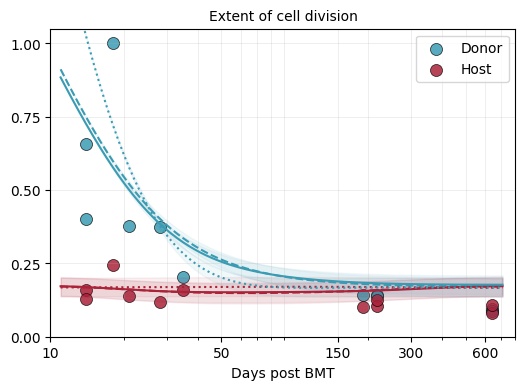

In [14]:
# Plot against days post BMT

tb1 = np.arange(52, 750,1) - 41
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_Ki67_bin2, x='Days postBMT', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.5,alpha=0.85, s=75, color='#3b9bb3')
sns.scatterplot(data=df_Ki67_bin2, x='Days postBMT', y='frac_Ki67+_MZ_host', edgecolor='black', linewidth=0.5, alpha=0.85, s=75, color='#ab2239')


plt.plot(tb1, np.mean(data_neutral_T1.host_ki_pred1, axis=0),  color='#ab2239', linestyle='dashed')
plt.fill_between(tb1, np.quantile(data_neutral_T1.host_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_T1.host_ki_pred1, 0.975, axis=0),  color='#ab2239', alpha=0.065)
plt.plot(tb1, np.mean(data_neutral_T1.donor_ki_pred1, axis=0), color='#3b9bb3', linestyle='dashed')
plt.fill_between(tb1, np.quantile(data_neutral_T1.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_T1.donor_ki_pred1, 0.975, axis=0), color='#3b9bb3', alpha=0.065)


plt.plot(tb1, np.mean(data_neutral_T2.host_ki_pred1 , axis=0),  color='#ab2239')
plt.fill_between(tb1, np.quantile(data_neutral_T2.host_ki_pred1 , 0.025, axis=0), np.quantile(data_neutral_T2.host_ki_pred1, 0.975, axis=0),  color='#ab2239', alpha=0.065)
plt.plot(tb1, np.mean(data_neutral_T2.donor_ki_pred1, axis=0), color='#3b9bb3')
plt.fill_between(tb1, np.quantile(data_neutral_T2.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_T2.donor_ki_pred1, 0.975, axis=0), color='#3b9bb3', alpha=0.065)


plt.plot(tb1, np.mean(data_neutral_FO.host_ki_pred1, axis=0), color='#ab2239', linestyle='dotted')
plt.fill_between(tb1, np.quantile(data_neutral_FO.host_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_FO.host_ki_pred1 , 0.975, axis=0), color= '#ab2239', alpha=0.065)
plt.plot(tb1, np.mean(data_neutral_FO.donor_ki_pred1, axis=0), color='#3b9bb3', linestyle='dotted')
plt.fill_between(tb1, np.quantile(data_neutral_FO.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_FO.donor_ki_pred1, 0.975, axis=0), color='#3b9bb3', alpha=0.065)


plt.xlim(10, 800)
plt.ylim(0, 1.05)
plt.xscale('log')
plt.xticks([10, 50, 150, 300, 600], [10, 50, 150, 300, 600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
# plt.ylabel('Proportion of Ki67+ MZ cells', fontsize=12)
plt.title('Extent of cell division', fontsize=10)
plt.xlabel('Days post BMT', fontsize=10)
plt.tick_params(axis='both', labelsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
plt.legend(labels=['Donor', 'Host'])
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_Ki67_daypostBMT.pdf', dpi=300)

plt.show() 

In [ ]:
from scipy.integrate import solve_ivp

def chi_source(time):
    """Chimerism source function"""
    chi_est = 0.83
    nu = 0.083
    t0 = 10
    
    if (time - t0) < 0:
        chi_s = 0
    else:
        chi_s = chi_est * (1 - np.exp(-nu * (time - t0)))
    
    return chi_s

def ode_system(t, X, phi, rho, age_at_bmt):
    """System of ODEs for MZ B cell dynamics"""
    P = 1298783
    eps_donor = 0.98
    eps_host = 0.95
    beta = 4.5
    
    M_stable = np.sum(X)
    delta = ((phi * P) / M_stable) + rho
    
    chi = chi_source(t - age_at_bmt)
    
    dXdt = np.zeros(4)
    
    # Donor Ki67+ cells
    dXdt[0] = (phi * eps_donor * chi * P 
               + rho * (X[0] + 2 * X[1]) 
               - ((1/beta) + delta) * X[0])
    
    # Donor Ki67- cells  
    dXdt[1] = (phi * (1 - eps_donor) * chi * P 
               + (1/beta) * X[0] 
               - (rho + delta) * X[1])
    
    # Host Ki67+ cells
    dXdt[2] = (phi * eps_host * (1 - chi) * P 
               + rho * (X[2] + 2 * X[3]) 
               - ((1/beta) + delta) * X[2])
    
    # Host Ki67- cells
    dXdt[3] = (phi * (1 - eps_host) * (1 - chi) * P 
               + (1/beta) * X[2] 
               - (rho + delta) * X[3])
    
    return dXdt

def solve_multiple_trajectories(initial_cond_t40, bmt_ages, solve_times, phi, rho):
    
    solutions = []
    
    for i, (bmt_age, solve_start) in enumerate(zip(bmt_ages, solve_times)):
        # Step 1: Generate initial conditions at BMT age from t=40
        ic_solution = solve_ivp(
            ode_system, (40, bmt_age), initial_cond_t40, args=(phi, rho, bmt_age)
        )
        initial_at_bmt = ic_solution.y[:, -1]
        
        # Step 2: Set up conditions at BMT
        y0_bmt = np.zeros(4)
        y0_bmt[0] = 0  # donor Ki67+ = 0
        y0_bmt[1] = 0  # donor Ki67- = 0  
        y0_bmt[2] = initial_at_bmt[0] + initial_at_bmt[2]  # host Ki67+ 
        y0_bmt[3] = initial_at_bmt[1] + initial_at_bmt[3]  # host Ki67-
        
        # Step 3: Solve from BMT to t=750
        time_points = np.arange(solve_start, 751, 1)
        trajectory_solution = solve_ivp(
            ode_system, (bmt_age, 750), y0_bmt, 
            t_eval=time_points, args=(phi, rho, bmt_age)
        )
        
        # Step 4: Calculate donor fraction
        donor_cells = trajectory_solution.y[0, :] + trajectory_solution.y[1, :]  # Total donor
        total_cells = np.sum(trajectory_solution.y, axis=0)  # Total cells at each time
        
        # Calculate NFD values for each time point
        nfd_values = []
        for j, t in enumerate(time_points):
            chi_factor = chi_source(t - bmt_age)
            if chi_factor > 0:  # Avoid division by zero
                nfd = donor_cells[j] / (total_cells[j] * chi_factor)
                nfd_values.append(nfd)
        
        nfd_values = np.array(nfd_values)
        
        # Calculate statistics
        mean_nfd_value = np.mean(nfd_values)
        quantiles_nfd_lower = np.quantile(nfd_values, 0.025)
        quantiles_nfd_upper = np.quantile(nfd_values, 0.975)
        
        # Create DataFrame for this BMT age and append to solutions
        solution_df = pd.DataFrame({
            'mean': [mean_nfd_value],
            'quantiles_lower': [quantiles_nfd_lower],
            'quantiles_upper': [quantiles_nfd_upper],
            'age_at_bmt': [bmt_age]
        })
        
        solutions.append(solution_df)
    
    # Combine all solutions into a single DataFrame based on age at BMT
    combined_solutions = pd.concat(solutions, ignore_index=True)    
    return combined_solutions

    
# For integration with your Bayesian analysis:
def solve_for_parameter_samples(initial_cond_t40, bmt_ages, solve_times, phi, rho):
    """
    Solve trajectories for multiple parameter samples (for Bayesian uncertainty)
    """
    n_samples = len(phi)
    all_solutions = []
    
    for sample_idx in range(n_samples):
            
        sample_solutions = solve_multiple_trajectories(
            initial_cond_t40,
            bmt_ages,
            solve_times, 
            phi[sample_idx],
            rho[sample_idx]
        )
        all_solutions.append(sample_solutions)
    
    return all_solutions

# Example usage with your specific data:
if __name__ == "__main__":
    # Your specific BMT ages and solve times
    bmt_ages = np.array([41, 42])
    # bmt_ages = np.array([41, 42, 51, 58, 65, 74, 87, 89, 101])
    
    solve_times = np.array([59, 124])
    # solve_times = np.array([59, 124, 141, 212, 158, 88, 731, 306, 291])
    
    
    # Example parameters (you'll use your actual estimated parameters)
    phi = data_neutral_T1.stan_variable('phi')  # influx rate
    rho = data_neutral_T1.stan_variable('rho') # division rate
    k0 = data_neutral_T1.stan_variable('kappa_0')
    y0 = data_neutral_T1.stan_variable('y0')
    host_ki67_plus = np.mean(k0*y0)
    host_ki67_minus = np.mean((1-k0)*y0)

    # Initial conditions at t=40
    initial_cond_t40 = np.array([0, 0, host_ki67_plus, host_ki67_minus])  # [donor_ki67+, donor_ki67-, host_ki67+, host_ki67-]

    # Solve all trajectories
    solutions = solve_for_parameter_samples(
        initial_cond_t40, 
        bmt_ages, 
        solve_times, 
        phi, 
        rho
    )

    print(solutions)

    # # Access results
    # for i, sol in enumerate(solutions):
    #     print(f"Nfd: {np.sum(sol['solution'][:2, -1]) / (np.sum(sol['solution'][:, -1]* chi_source(sol['solve_start'] - sol['bmt_age'])))}")
        



[       mean  quantiles_lower  quantiles_upper  age_at_bmt
0  0.772130         0.101393         0.986485          41
1  0.833316         0.383441         0.986539          42,        mean  quantiles_lower  quantiles_upper  age_at_bmt
0  0.884411         0.194105         0.999843          41
1  0.943393         0.623897         0.999844          42,        mean  quantiles_lower  quantiles_upper  age_at_bmt
0  0.849179         0.151609         0.998702          41
1  0.910622         0.525012         0.998710          42,        mean  quantiles_lower  quantiles_upper  age_at_bmt
0  0.842350         0.145410          0.99825          41
1  0.904008         0.508981          0.99826          42,        mean  quantiles_lower  quantiles_upper  age_at_bmt
0  0.872508         0.177394         0.999634          41
1  0.932615         0.587087         0.999636          42,        mean  quantiles_lower  quantiles_upper  age_at_bmt
0  0.843373         0.146289         0.998324          41
1  0.905